# Домашнее задание 5

## Тема: линейные модели и честный ML-эксперимент

Ноутбук HW05.ipynb содержит:

корректную загрузку датасета S05-hw-dataset.csv в pandas.DataFrame;
первичный анализ данных: head, info, describe (или аналог) + анализ распределения таргета default;
выделение матрицы признаков X и таргета y (с исключением client_id из признаков);
разбиение данных на train/test с фиксированным random_state и осмысленными параметрами test_size и stratify;
реализацию бейзлайн-модели на основе DummyClassifier и вычисление хотя бы двух метрик (включая accuracy);
реализацию логистической регрессии в виде Pipeline (скейлер + модель) и подбор хотя бы одного гиперпараметра (C);
сравнение качества бейзлайна и логистической регрессии на тестовой выборке по accuracy и ROC-AUC;
краткий текстовый отчёт с выводами по результатам эксперимента.
Хотя бы один график (например, ROC-кривая) либо:

построен прямо в ноутбуке,
либо дополнительно сохранён в файл в структуре репозитория (homeworks/HW05/figures/).
Код выполняется без ошибок при последовательном запуске всех ячеек ноутбука.

Дополнительно поощряется (но не обязательно для зачёта):

аккуратные подписи осей, легенд и заголовков графиков;
использование дополнительных метрик и осмысленных графиков (PR-кривая, confusion matrix и т.п.);
наличие опциональной части (калибровка, сравнение с другой моделью и т.д.);
внятные и понятные текстовые комментарии, связывающие результаты метрик с логикой задачи.

In [65]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    brier_score_loss,
)
from sklearn.calibration import CalibratedClassifierCV
import math


RANDOM_STATE = 42

DATA_PATH = 'data/'
FIG_PATH = 'figures/'
ART_PATH = 'artifacts/'

# Загрузка данных и первичный анализ 

In [36]:
df = pd.read_csv(DATA_PATH+'S05-hw-dataset.csv')
df.head()


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


In [37]:
df.info()

df.describe().transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

,count,mean,std,min,25%,50%,75%,max
client_id,3000.0,1500.500000,866.169729,1.000000,750.750000,1500.500000,2250.250000,3000.000000
age,3000.0,45.059667,14.192883,21.000000,33.000000,45.000000,57.000000,69.000000
income,3000.0,69658.992000,24742.235182,15000.000000,52641.750000,69784.500000,85874.250000,156351.000000
years_employed,3000.0,19.577667,11.381497,0.000000,10.000000,20.000000,29.000000,39.000000
credit_score,3000.0,649.285333,69.955852,402.000000,604.000000,647.000000,697.000000,850.000000
debt_to_income,3000.0,0.284065,0.161112,0.006147,0.157796,0.261726,0.388886,0.878343
num_credit_cards,3000.0,3.494667,2.289917,0.000000,1.000000,3.000000,6.000000,7.000000
num_late_payments,3000.0,6.869333,4.291278,0.000000,3.000000,7.000000,10.000000,14.000000
has_mortgage,3000.0,0.495000,0.500058,0.000000,0.000000,0.000000,1.000000,1.000000
has_car_loan,3000.0,0.501333,0.500082,0.000000,0.000000,1.000000,1.000000,1.000000


In [38]:
df['default'].value_counts(normalize=True)

default
0    0.589667
1    0.410333
Name: proportion, dtype: float64

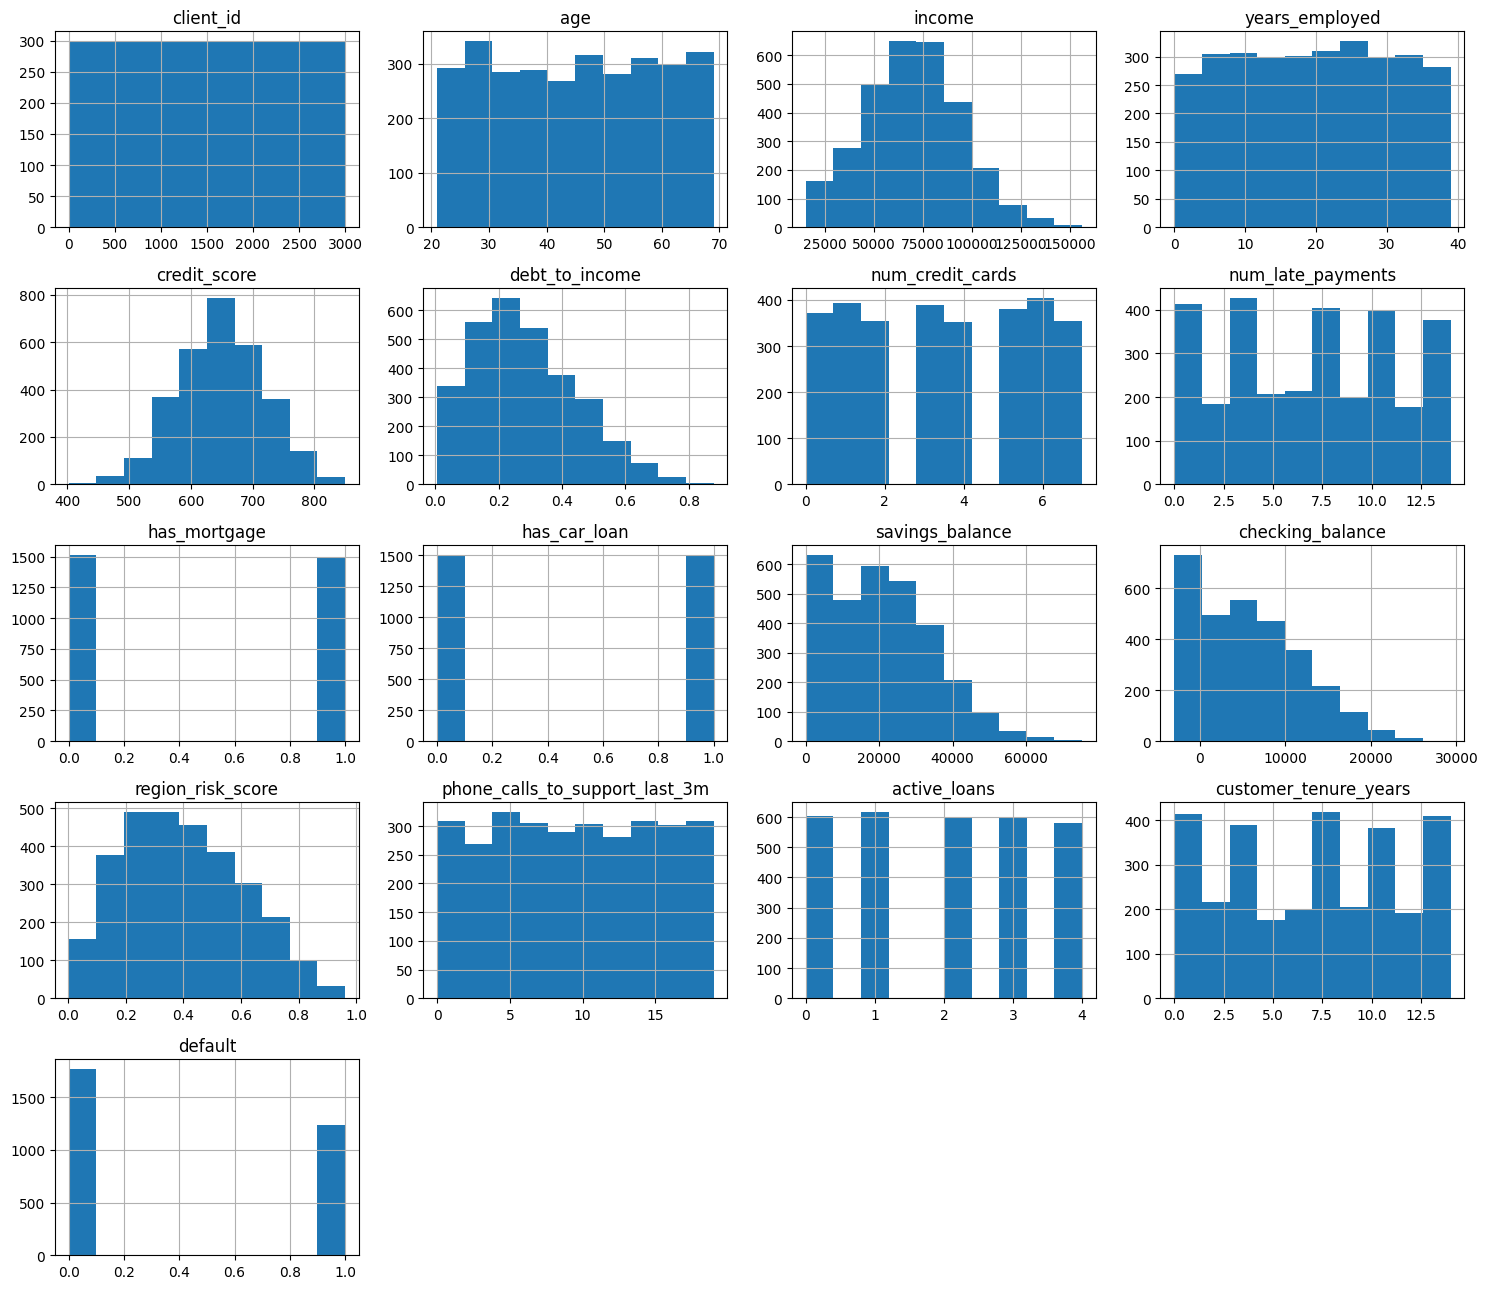

In [39]:
ax = df.hist(figsize=(15, 13))

plt.tight_layout()                       
plt.savefig(FIG_PATH+"hist_all_columns.png", dpi=300)

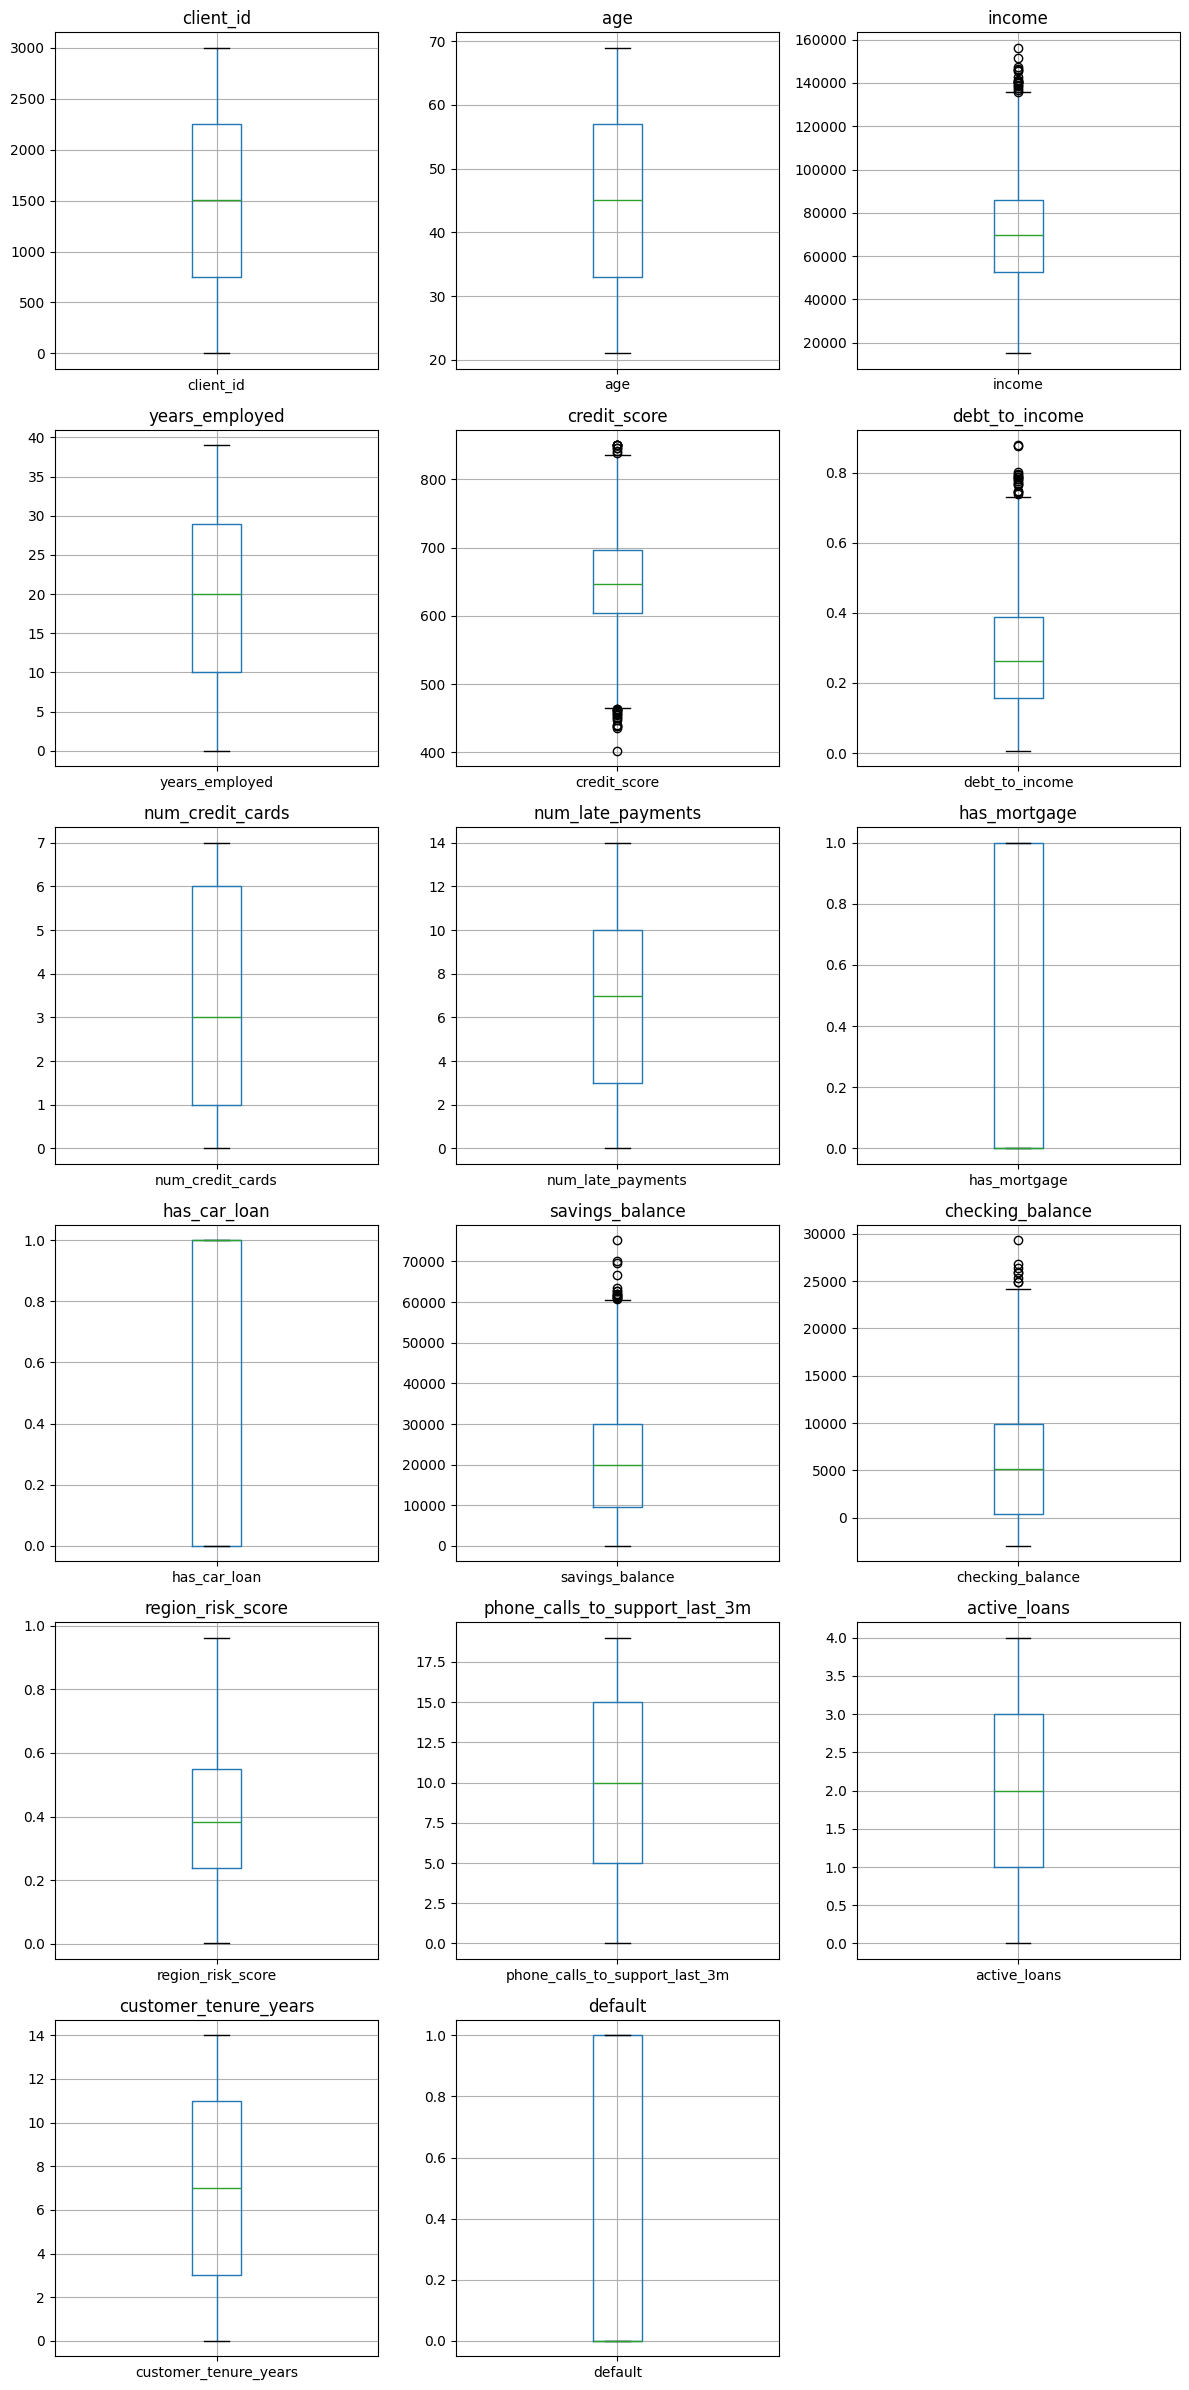

In [40]:

num_cols = df.select_dtypes(include="number").columns
n = len(num_cols)

n_cols = 3                       # сколько графиков в строке
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")            

# скрываем пустые ячейки, если графиков меньше, чем слотов
for ax in axes[len(num_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(FIG_PATH+"boxplot_all_columns.png", dpi=300)
plt.show()

    Данные представляют собой исключительно числовые значения. Три столбца имеют бинарное распределение. Стаж сотрудников максимально случайный в интерале от 0 до 40 лет. ID клиента можно удалить, так как он уникален для каждого пользователя.

    Значения имеют разные масштабы, а значит их нужно будет масштабировать для корректной работы Линейной регрессии. Пропусков в данных нет. Одиноких выбросов нет, обычно значения распределены либо бинарно, либо близко раваномерному или нормальному распределению.

    Классы распределены равномерно. Всего в датасете 3000 строчек.

# Подготовка признаков и таргета

In [41]:
X = df.drop(columns=['client_id','default'])
y = df['default']

    Валидность признаков проверять не требуется, так как исходя из info и ящиков с усами, все признаки принимают корректные значения, все признаки числовые и находятся в адекватном диапазоне.

# Train/Test-сплит

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,         
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,      
    stratify=y_train,
    random_state=RANDOM_STATE,
)

    Мы поделили X и y на тестовую, обучающую и валидационную выборки. Это сделано для грамотной оценки обобщающей способности модели.

In [43]:
print("Размеры выборок:")
print("  train:", X_train.shape)
print("  val:  ", X_val.shape)
print("  test: ", X_test.shape)

print("\nРаспределение классов (train):")
print(y_train.value_counts(normalize=True))

print("\nРаспределение классов (val):")
print(y_val.value_counts(normalize=True))

print("\nРаспределение классов (test):")
print(y_test.value_counts(normalize=True))

Размеры выборок:
  train: (1800, 15)
  val:   (600, 15)
  test:  (600, 15)

Распределение классов (train):
default
0    0.589444
1    0.410556
Name: proportion, dtype: float64

Распределение классов (val):
default
0    0.59
1    0.41
Name: proportion, dtype: float64

Распределение классов (test):
default
0    0.59
1    0.41
Name: proportion, dtype: float64


    Как видим, классы распредедлены примерно равномерно. (Благодаря параметру stratify)

# Baseline-модель

In [46]:
baseline = DummyClassifier(
    strategy="stratified",
    random_state=RANDOM_STATE
)
baseline.fit(X_train,y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'stratified'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [47]:
y_val_pred_baseline = baseline.predict(X_val)
y_val_proba_baseline = baseline.predict_proba(X_val)[:, 1]

print("Accuracy :", accuracy_score(y_val, y_val_pred_baseline))
print("Precision:", precision_score(y_val, y_val_pred_baseline, zero_division=0))
print("Recall   :", recall_score(y_val, y_val_pred_baseline, zero_division=0))
print("F1-score :", f1_score(y_val, y_val_pred_baseline, zero_division=0))

Accuracy : 0.5133333333333333
Precision: 0.4108527131782946
Recall   : 0.43089430894308944
F1-score : 0.42063492063492064


    Как видим, наша модель близка к случайному угадыванию, и любая более умная модель должна выдавать метрики лучше, чем бейзлайн.

# Логистическая регрессия

In [74]:
log_reg_pipeline = Pipeline(
    steps = [
    ("scaler", StandardScaler()),
    ("logreg", 
        LogisticRegression(
            max_iter=1000,
            l1_ratio=0,
            C=1.0,
            solver='liblinear',
            random_state=RANDOM_STATE,
        ),
    ),
])

log_reg_pipeline.fit(X_train, y_train)

y_val_pred_baseline = log_reg_pipeline.predict(X_val)
y_val_proba_baseline = log_reg_pipeline.predict_proba(X_val)[:, 1]

print("Accuracy :", accuracy_score(y_val, y_val_pred_baseline))
print("Precision:", precision_score(y_val, y_val_pred_baseline, zero_division=0))
print("Recall   :", recall_score(y_val, y_val_pred_baseline, zero_division=0))
print("F1-score :", f1_score(y_val, y_val_pred_baseline, zero_division=0))

Accuracy : 0.8166666666666667
Precision: 0.8505154639175257
Recall   : 0.6707317073170732
F1-score : 0.75


In [67]:
joblib.dump(baseline,ART_PATH+"baseline.joblib")

['artifacts/baseline.joblib']

    Из параметров - ничего не поменяла, так как датасет маленький и лучшая стратегия оптимизации - координатный спуск (она работает только с l1 и l2 (без elasticnet) регуляризацией). Для новых версий sklearn актуальна запись l1_ratio: float - доля l1 в elasticnet (l2 - доля l1 0, l1 - 1.0, elasticnet - 0.5)

    Мы видим, что результат на каждой метрике значительно улучшился, но все равно < 0.9 верных. Проведем полный перебор параметров регрессии.

# Подбор гиперпараметров

In [69]:
# Настроим сетку по параметру C (сила регуляризации)
param_grid = {
    "logreg__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "logreg__l1_ratio": [0.0,1.0],
}


grid_search = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=param_grid,
    scoring="accuracy",   
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший accuracy (по CV):", grid_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Лучшие параметры: {'logreg__C': 0.1, 'logreg__l1_ratio': 1.0}
Лучший accuracy (по CV): 0.7833333333333333


In [70]:
# Берём лучшую найденную модель
best_model = grid_search.best_estimator_

# Оцениваем на validation
y_val_pred_best = best_model.predict(X_val)
y_val_proba_best = best_model.predict_proba(X_val)[:, 1]

print("=== Лучшая модель – качество на validation ===")
print("Accuracy :", accuracy_score(y_val, y_val_pred_best))
print("Precision:", precision_score(y_val, y_val_pred_best, zero_division=0))
print("Recall   :", recall_score(y_val, y_val_pred_best, zero_division=0))
print("F1-score :", f1_score(y_val, y_val_pred_best, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_val, y_val_proba_best))

# Оцениваем на test
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== Лучшая модель – качество на test ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_test_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_test_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_proba))

=== Лучшая модель – качество на validation ===
Accuracy : 0.8083333333333333
Precision: 0.8291457286432161
Recall   : 0.6707317073170732
F1-score : 0.7415730337078652
ROC-AUC  : 0.8741100546598687

=== Лучшая модель – качество на test ===
Accuracy : 0.8016666666666666
Precision: 0.7981220657276995
Recall   : 0.6910569105691057
F1-score : 0.7407407407407407
ROC-AUC  : 0.8756832483579073


In [71]:
target_names = ['0','1']

print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred, target_names=target_names))


Classification report (test):
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       354
           1       0.80      0.69      0.74       246

    accuracy                           0.80       600
   macro avg       0.80      0.78      0.79       600
weighted avg       0.80      0.80      0.80       600



    Мы видим, что модель с оптимальными параметрами показывает неплохие результаты.

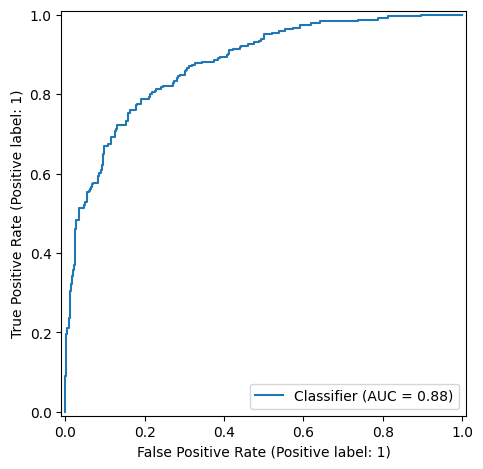

In [72]:
RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
)
plt.tight_layout()                       
plt.savefig(FIG_PATH+"ROC_curve", dpi=300)

In [ ]:
joblib.dump(log_reg_pipeline,ART_PATH+"logreg.joblib")
joblib.dump(best_model,ART_PATH+"best_logreg.joblib")

['artifacts/logreg.joblib']

    Модель была сохранена через joblib. Вывод - модель с подобранными ги перпараметрами показывает себя не сильно лучше, чем с первыми попавшимися. Так как параметров перебиралось немного, это не заняло у нас много времени. Наша модель показала лучшие результаты, по сравнению с бейзлайном.

    Лучшие параметры - более сильные штрафы и модульная регуляризация l1. Из-за смены параметров модель не сильно прибавила в скоре, скорее значения стали более равномерными. Предполагаю, что это связано с уменьшением кол-ва обучающих данных из-за кросс-валидации.

    Для данного датасета являлось корректно смотреть на accuracy, так как классы сбалансированны.

# Catboost pipeline

    Добавим вторую модель, для сравнения и улучшения параметров (вообще, сравнивать бустинг и логистическую регрессию немного нечестно)